# GW1 2026/27 — Building the Squad

This notebook shows the whole build, start to finish. Run it top to bottom and it
reproduces the squad in [`GW1_2026_27_SELECTION_REPORT.md`](../GW1_2026_27_SELECTION_REPORT.md).

The logic lives in [`scripts/build_gw1_squad.py`](../scripts/build_gw1_squad.py) so the
notebook and the command-line script can never drift apart. Here we import those
functions, run them one at a time, and look at what each step produces.

**What we are doing.** We combine two sources. The live 2026/27 API tells us who plays
where, for how much, and against whom. Last season's data tells us how good they are.
Then a solver picks the best legal 15-player squad.

**The one rule that shapes everything:** availability gates everything. A player who
does not play scores nothing, no matter how good he is.

In [1]:
import json, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO / "scripts"))

import build_gw1_squad as gw1

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
plt.rcParams.update({"figure.figsize": (9, 4.5), "axes.grid": True, "grid.alpha": 0.25})
print("repo:", REPO)

repo: /Users/djay/Documents/fpl-retrospective-codex-starter


## 1. Load both seasons

`load_live_data` caches a dated snapshot of the API under `data/raw/`, so this notebook
gives the same answer tomorrow as it does today. Pass `offline=False` to pull fresh data.

In [2]:
bootstrap, fixtures = gw1.load_live_data(offline=True)
season = gw1.load_last_season()
bridge = gw1.load_id_code_bridge()

teams = {t["id"]: t["name"] for t in bootstrap["teams"]}
print(f"new season : {len(bootstrap['elements'])} players, {len(teams)} clubs, {len(fixtures)} fixtures")
print(f"last season: {len(season):,} player-gameweek rows, {season.player_id.nunique()} players")
print(f"GW1 deadline: {bootstrap['events'][0]['deadline_time']}")

old_clubs = {t["name"] for t in json.loads((REPO / "data/raw/bootstrap_static_smoke.json").read_text())["teams"]}
print("promoted:", sorted(set(teams.values()) - old_clubs))
print("relegated:", sorted(old_clubs - set(teams.values())))

new season : 558 players, 20 clubs, 380 fixtures
last season: 29,747 player-gameweek rows, 841 players
GW1 deadline: 2026-08-21T17:30:00Z
promoted: ['Coventry City', 'Hull City', 'Ipswich Town']
relegated: ['Burnley', 'West Ham', 'Wolves']


## 2. Join the seasons, then prove the join is right

A player's `id` changes every season. His `code` never does. Last season's file maps one
to the other, so we join through the code.

A join you have not checked is a join you cannot trust. Luckily the API still carries each
player's 2025/26 totals, which gives us a completely independent copy of the same numbers.
If our join is correct, the two should agree.

In [3]:
api = pd.DataFrame([
    {"code": e["code"], "name": e["web_name"], "api_points": e["total_points"],
     "api_minutes": e["minutes"], "api_xgi": float(e["expected_goal_involvements"] or 0)}
    for e in bootstrap["elements"]
])
ours = season.groupby("player_id").agg(
    points=("total_points", "sum"), minutes=("minutes", "sum"),
    xgi=("expected_goal_involvements", "sum")).reset_index()
ours["code"] = ours.player_id.map(bridge)

check = api.merge(ours.dropna(subset=["code"]), on="code")
both = check[(check.api_minutes > 0) & (check.minutes > 0)]

print(f"players matched by code : {len(check)} of {len(api)}")
print(f"with a record on both sides: {len(both)}")
for label, a, b in [("points", both.api_points, both.points),
                    ("minutes", both.api_minutes, both.minutes),
                    ("xGI", both.api_xgi, both.xgi)]:
    agree = (np.abs(a - b) < 0.02).sum()
    print(f"  exact agreement on {label:8s}: {agree}/{len(both)} ({100*agree/len(both):.1f}%)")

print("\nthe disagreements:")
display(both[np.abs(both.api_points - both.points) >= 0.02][
    ["name", "api_points", "points", "api_minutes", "minutes"]])

players matched by code : 454 of 558
with a record on both sides: 400
  exact agreement on points  : 399/400 (99.8%)
  exact agreement on minutes : 399/400 (99.8%)
  exact agreement on xGI     : 399/400 (99.8%)

the disagreements:


,name,api_points,points,api_minutes,minutes
49,Gomes,85,107,2207,2829


**What this tells us.** 399 of 400 players agree exactly on points, minutes *and* expected
goal involvement. The join is sound.

The one exception is a stale row in our own repo snapshot, not a flaw in the method. Four
more players show the same drift with zero minutes on one side. We handle all five the same
way: where our files disagree with the API, we believe the API, and we throw away our
defensive numbers for those players rather than trust them.

## 3. Let the data choose the weights

This is the step that keeps the model honest. Rather than deciding how much to trust each
signal, we split last season down the middle, measure each player over the first half, and
check which measurement actually predicted the second half.

In [4]:
backtest = gw1.run_backtest(season)
display(backtest.table.round(3))
print("weight placed on xGI (the rest goes on points per 90):")
for pos, w in backtest.weights.items():
    print(f"  {pos}: {w:.0%}")

,position,n_rate,n_total,pp90_to_future_rate,xgi90_to_future_rate,minutes_to_future_points,points_to_future_points
0,GKP,21,25,-0.105,0.168,0.483,0.368
1,DEF,95,110,0.220,0.187,0.491,0.442
2,MID,112,142,0.344,0.448,0.459,0.514
3,FWD,28,32,0.173,0.466,0.590,0.540


weight placed on xGI (the rest goes on points per 90):
  GKP: 0%
  DEF: 46%
  MID: 57%
  FWD: 73%


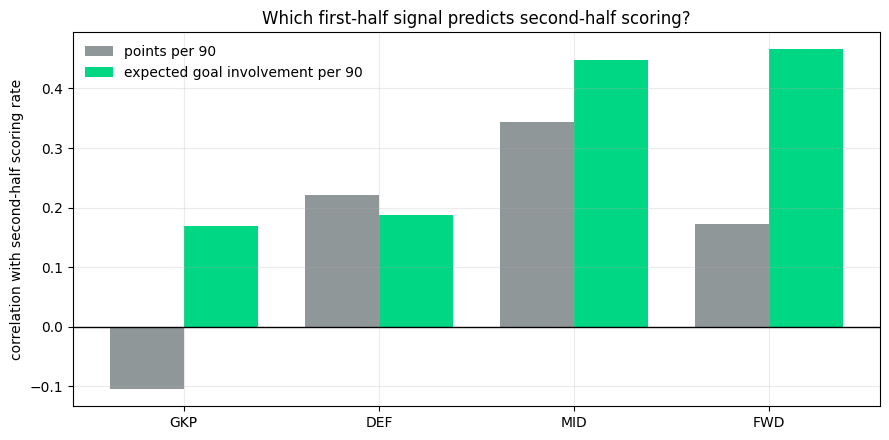

In [5]:
t = backtest.table.set_index("position").loc[["GKP", "DEF", "MID", "FWD"]]
x = np.arange(len(t)); w = 0.38
fig, ax = plt.subplots()
ax.bar(x - w/2, t.pp90_to_future_rate, w, label="points per 90", color="#8F9798")
ax.bar(x + w/2, t.xgi90_to_future_rate, w, label="expected goal involvement per 90", color="#00D785")
ax.axhline(0, color="black", lw=1)
ax.set_xticks(x); ax.set_xticklabels(t.index)
ax.set_ylabel("correlation with second-half scoring rate")
ax.set_title("Which first-half signal predicts second-half scoring?")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

**Read the chart from right to left.**

For **forwards**, expected goal involvement (0.47) crushes raw points per 90 (0.17). Past
goals barely predict future goals. The quality of chances a striker gets does. Midfielders
show the same pattern, more gently.

For **goalkeepers**, the points-per-90 bar sits *below zero*. A keeper who scored well early
was, if anything, slightly worse later. Keeper scoring rate is unpredictable, full stop. So
we buy keepers on minutes and defensive quality alone, and never pay a premium.

These measured numbers become the model's weights directly — 73% on xGI for forwards, 57%
for midfielders, 46% for defenders, and 0% for keepers.

## 4. Does the whole thing beat just picking last season's best scorers?

Individual signals looking good is not the same as the finished model working. So we rebuild
the *entire* projection using first-half data only, and score it against the second half.

In [6]:
validation = gw1.validate_projection(season, backtest)
display(validation)

,method,spearman_vs_h2_points,mean_h2_points_of_top20,rho_DEF,rho_FWD,rho_GKP,rho_MID
0,assembled projection,0.520,76.0,0.503,0.598,0.408,0.532
1,baseline: H1 total points,0.475,67.8,0.442,0.540,0.368,0.514
2,baseline: H1 points per 90,0.181,58.0,0.169,0.014,0.263,0.233
3,baseline: H1 minutes,0.447,67.4,0.491,0.590,0.483,0.459
4,baseline: price,0.288,75.7,0.353,0.320,0.411,0.330


Our projection wins on both measures. Its top 20 picks went on to score **76.0 points each**,
against **67.8** for simply ranking players by last season's points.

But those weights were learned on the same split we just tested on. So here is a stricter
version: learn the weights on gameweeks 1–12, then score on gameweeks 25–38 — a stretch of
the season the weights never saw.

In [7]:
oos_weights = gw1.run_backtest(season[season.gameweek <= 24], split=12, min_minutes=300)
validation_oos = gw1.validate_projection(season, oos_weights, split=24)
display(validation_oos[["method", "spearman_vs_h2_points", "mean_h2_points_of_top20"]])

edge = (validation_oos.mean_h2_points_of_top20.iloc[0] - validation_oos.mean_h2_points_of_top20.iloc[1])
print(f"out-of-sample edge over the obvious method: {edge:.1f} points per player over 14 gameweeks")
print(f"which is about {edge/14:.2f} points per player per gameweek")

,method,spearman_vs_h2_points,mean_h2_points_of_top20
0,assembled projection,0.522,57.8
1,baseline: H1 total points,0.498,54.8
2,baseline: H1 points per 90,0.182,39.7
3,baseline: H1 minutes,0.465,52.4
4,baseline: price,0.261,55.4


out-of-sample edge over the obvious method: 3.0 points per player over 14 gameweeks
which is about 0.21 points per player per gameweek


**Keep this in proportion.** The edge survives a genuine out-of-sample test, and it points
the same way in both runs. But it is worth roughly **0.2 points per player per gameweek**.
That is an edge worth having. It is not a reason to override something you can see with your
own eyes.

Note too that the forward weight swung a lot between the two runs. Only 32 forwards had
enough minutes to measure. The forward picks are the least stable part of the squad.

## 5. Build the player pool and project every player

Now we apply the weights to the new season. Two ideas do the heavy lifting.

**Separate rate from volume.** How well a player scores when he is on the pitch is a
different question from how much of each match he plays. A season lost to injury tells you
about the second and nothing about the first, so we estimate them apart and multiply.

**Never count the same points twice.** Defensive contributions are worth real points, and
the API does not carry them across seasons — so we take them from our own files. But a
player's points per 90 *already includes* the defensive points he earned. We therefore add
only how far he sits from the positional average, and only to the part of the estimate that
was blind to defending.

In [8]:
pool, diagnostics = gw1.build_pool(bootstrap, fixtures, season, bridge, backtest)
pool = gw1.project(pool, backtest)
print(json.dumps(diagnostics, indent=1))

available = pool[pool.available & (pool.history != "none")]
display(available.nlargest(12, "xp")[
    ["name", "club", "position", "price", "ls_minutes", "ls_points",
     "pp90", "xgi90", "rate_per_90", "proj_minutes", "xp", "xp_per_million"]].round(2))

{
 "n_players": 558,
 "history_counts": {
  "full": 378,
  "none": 158,
  "mover": 22
 },
 "dc_codes_matched": 399,
 "dc_codes_rejected_stale_mapping": 5
}


,name,club,position,price,ls_minutes,ls_points,pp90,xgi90,rate_per_90,proj_minutes,xp,xp_per_million
411,Haaland,Man City,FWD,15.5,2953.0,239.0,7.28,0.86,6.58,75.79,5.58,0.36
430,B.Fernandes,Man Utd,MID,12.0,3065.0,235.0,6.90,0.68,5.92,78.25,5.28,0.44
104,Thiago,Brentford,FWD,8.0,3282.0,181.0,4.96,0.62,5.38,82.63,4.94,0.62
397,Semenyo,Man City,MID,8.5,3200.0,202.0,5.68,0.40,4.91,80.77,4.43,0.52
12,Rice,Arsenal,MID,7.5,3093.0,184.0,5.35,0.30,4.95,78.52,4.37,0.58
3,Gabriel,Arsenal,DEF,8.0,2750.0,209.0,6.84,0.15,5.34,71.29,4.31,0.54
355,Virgil,Liverpool,DEF,6.5,3420.0,175.0,4.61,0.14,4.43,86.13,4.31,0.66
483,Gibbs-White,Nott'm Forest,MID,8.0,3101.0,188.0,5.46,0.40,4.72,78.95,4.22,0.53
155,Enzo,Chelsea,MID,7.0,3114.0,157.0,4.54,0.54,4.78,78.78,4.19,0.60
367,Szoboszlai,Liverpool,MID,7.0,3232.0,160.0,4.46,0.32,4.56,81.43,4.18,0.60


### Where the value sits

Points per pound, by position. This is the reason we spend down in defence and up in attack.

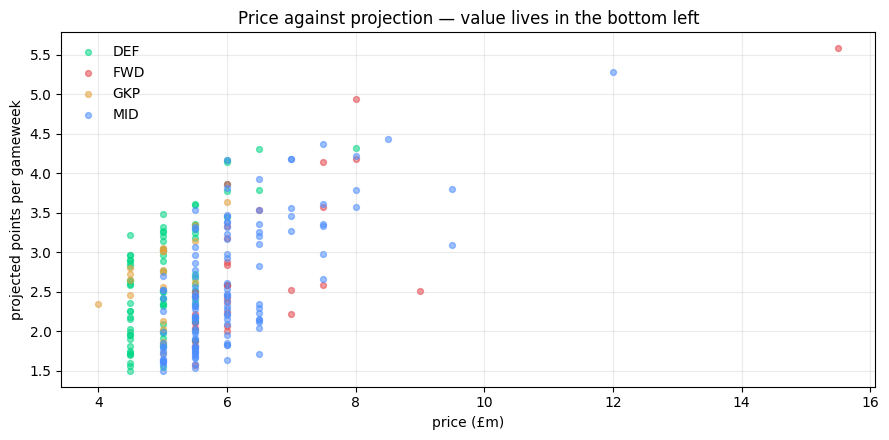

best points per £m, minimum projection of 2.5:


,name,club,position,price,xp,xp_per_million
203,Mitchell,Crystal Palace,DEF,4.5,3.22,0.71
472,N.Williams,Nott'm Forest,DEF,5.0,3.48,0.70
388,Guéhi,Man City,DEF,6.0,4.17,0.69
238,Garner,Everton,MID,6.0,4.17,0.69
229,Tarkowski,Everton,DEF,6.0,4.14,0.69
497,Van Hecke,Spurs,DEF,5.0,3.32,0.66
355,Virgil,Liverpool,DEF,6.5,4.31,0.66
427,Shaw,Man Utd,DEF,4.5,2.97,0.66
87,Kayode,Brentford,DEF,4.5,2.96,0.66
537,Mukiele,Sunderland,DEF,5.5,3.61,0.66


In [9]:
fig, ax = plt.subplots()
colours = {"GKP": "#E5A23D", "DEF": "#00D785", "MID": "#4C8DFF", "FWD": "#E5484D"}
for pos, g in available[available.xp > 1.5].groupby("position"):
    ax.scatter(g.price, g.xp, s=18, alpha=0.55, label=pos, color=colours[pos])
ax.set_xlabel("price (£m)"); ax.set_ylabel("projected points per gameweek")
ax.set_title("Price against projection — value lives in the bottom left")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

print("best points per £m, minimum projection of 2.5:")
display(available[available.xp > 2.5].nlargest(10, "xp_per_million")[
    ["name", "club", "position", "price", "xp", "xp_per_million"]].round(2))

The top of that value list is almost entirely defenders. Cheap defenders who play every
minute and rack up defensive contributions are the most efficient points in the game. That
is what funds a £15.5m striker.

## 6. Pick the squad with a solver

We do not hand-pick anyone. The whole problem goes to a mixed integer linear program.

Why a solver rather than "buy the best value player, then repeat"? Because every pick changes
what you can afford next, and a greedy rule cannot see that. The solver weighs all the
trade-offs at once and *proves* its answer is the best one available.

Every rule comes from the API's own game settings, so this stays correct if FPL ever changes
them: 15 players, 2 keepers, 5 defenders, 5 midfielders, 3 forwards, £100.0m, at most 3 per
club, and a legal formation. The captain scores double, so the solver chooses him too.

In [10]:
solution = gw1.optimise(pool, bootstrap)
squad = solution.squad
print(f"solver status: {solution.status}   (Optimal = no legal squad scores higher)")
print(f"spend: £{squad.price.sum():.1f}m of £{bootstrap['game_settings']['squad_total_spend']/10:.1f}m")

xi = squad[squad.is_starter]
print(f"formation: {(xi.position=='DEF').sum()}-{(xi.position=='MID').sum()}-{(xi.position=='FWD').sum()}")
print(f"most players from one club: {squad.club.value_counts().max()} (limit is {bootstrap['game_settings']['squad_team_limit']})")

display(squad[["name", "full_name", "position", "club", "price", "is_starter", "is_captain",
               "ls_minutes", "ls_points", "xp", "ownership", "gw1_opp", "gw1_home"]].round(2))
print("bench order:", " > ".join(gw1.bench_order(squad)["name"]))

solver status: Optimal   (Optimal = no legal squad scores higher)
spend: £100.0m of £100.0m
formation: 3-4-3
most players from one club: 2 (limit is 3)


,name,full_name,position,club,price,is_starter,is_captain,ls_minutes,ls_points,xp,ownership,gw1_opp,gw1_home
0,Raya,David Raya Martín,GKP,Arsenal,6.0,True,False,3330.0,162.0,3.64,29.8,COV,True
342,Virgil,Virgil van Dijk,DEF,Liverpool,6.5,True,False,3420.0,175.0,4.31,15.3,NEW,False
371,Guéhi,Marc Guéhi,DEF,Man City,6.0,True,False,3150.0,179.0,4.17,25.4,BOU,True
218,Tarkowski,James Tarkowski,DEF,Everton,6.0,True,False,3330.0,170.0,4.14,10.9,CRY,True
9,Rice,Declan Rice,MID,Arsenal,7.5,True,False,3093.0,184.0,4.37,22.5,COV,True
145,Enzo,Enzo Fernández,MID,Chelsea,7.0,True,False,3114.0,157.0,4.19,5.1,FUL,False
352,Szoboszlai,Dominik Szoboszlai,MID,Liverpool,7.0,True,False,3232.0,160.0,4.18,40.4,NEW,False
227,Garner,James Garner,MID,Everton,6.0,True,False,3413.0,159.0,4.17,4.1,CRY,True
393,Haaland,Erling Haaland,FWD,Man City,15.5,True,True,2953.0,239.0,5.58,73.5,BOU,True
97,Thiago,Igor Thiago Nascimento Rodrigues,FWD,Brentford,8.0,True,False,3282.0,181.0,4.94,17.9,TOT,True


bench order: Ampadu > Mitchell > Shaw > Dubravka


## 7. Stress-test the answer

A single optimal squad means nothing if a small change to the assumptions rewrites it. So we
re-run the whole optimisation four ways.

In [11]:
sens = gw1.run_sensitivities(pool, bootstrap, solution)
display(sens)

,variant,status,squad_overlap_with_primary,changed,captain,spend,objective
0,no_new_player_rule,Optimal,15,0,Haaland,100.0,54.57
1,fpl_own_ep_next,Optimal,3,12,B.Fernandes,100.0,39.08
2,ignore_fixtures,Optimal,14,1,Haaland,100.0,54.19
3,bench_weight_zero,Optimal,10,5,Haaland,100.0,53.48


**Fixtures break ties, they do not drive picks.** Switching fixtures off entirely changes one
player out of fifteen. That matches what our earlier season-long analysis found, and it is
why we give fixtures only a small nudge.

**The captain is not in doubt.** Haaland captains every version but one.

**The bench weighting is the real judgment call.** How much a bench player is worth changes
five of the fifteen picks, and no data settles it. We assume a bench player is worth about
12% of a starter, which is roughly how often they come on.

**Ignore FPL's own forecast.** Only four players in the entire game are rated above 3.3 in
their pre-season number — it has almost no resolution yet, so its disagreement means nothing.

Finally, we test every starter against the best cheaper player at his position.

In [12]:
rivals = gw1.cheaper_rival_test(pool, solution)
display(rivals.head(6))

,starter,position,price,xp,best_cheaper,rival_price,rival_xp,xp_given_up,saving
5,Enzo,MID,7.0,4.19,Anderson,6.5,3.92,0.26,0.5
6,Szoboszlai,MID,7.0,4.18,Anderson,6.5,3.92,0.26,0.5
0,Raya,GKP,6.0,3.64,Donnarumma,5.5,3.34,0.30,0.5
1,Virgil,DEF,6.5,4.31,Senesi,6.0,3.87,0.44,0.5
4,Rice,MID,7.5,4.37,Anderson,6.5,3.92,0.45,1.0
3,Tarkowski,DEF,6.0,4.14,Mukiele,5.5,3.61,0.53,0.5


The two closest calls are the ones to revisit if news changes before the deadline. Everything
below them gives up more than half a point per gameweek to save half a million.

## 8. What the model refuses to decide

The model only knows last season. These are the players where it has no evidence, and where
your own judgment has to take over.

In [13]:
blind = pool[pool.available & (pool.price >= 7.0) & (pool.proj_minutes < 60)]
display(blind.nlargest(6, "price")[
    ["name", "full_name", "club", "position", "price", "ls_minutes", "ls_starts",
     "proj_minutes", "xp"]].round(1))

no_history = pool[pool.history == "none"]
print(f"{len(no_history)} players have no Premier League record at all")
print(no_history.club.value_counts().head(4).to_string())

,name,full_name,club,position,price,ls_minutes,ls_starts,proj_minutes,xp
154,Palmer,Cole Palmer,Chelsea,MID,9.5,1954.0,24.0,55.7,3.1
378,Isak,Alexander Isak,Liverpool,FWD,9.0,694.0,8.0,46.7,2.5
24,Gyökeres,Viktor Gyökeres,Arsenal,FWD,7.5,2217.0,26.0,60.0,3.6
25,Havertz,Kai Havertz,Arsenal,FWD,7.5,577.0,7.0,43.7,2.6
77,Kroupi.Jr,Junior Kroupi,Bournemouth,MID,7.5,1663.0,21.0,50.0,2.7
399,Cherki,Rayan Cherki,Man City,MID,7.5,1772.0,19.0,53.4,3.3


158 players have no Premier League record at all
club
Hull City        28
Coventry City    27
Ipswich Town     26
Liverpool        13


**Alexander Isak is the big one.** He played 694 minutes last season, so the model has no
evidence he plays and leaves him out at £9.0m. If you know he is fit and starting for
Liverpool, the model is wrong and you are right. That is exactly the kind of call it cannot
make for you.

The 158 players with no Premier League record are barred from the starting XI by design.
Price is the only clue to how good they are, and price is not evidence. Lifting that rule
changed nothing — the solver picked the same fifteen anyway.

---

## The squad

**3-4-3, £100.0m spent exactly, Erling Haaland captain.**

Raya · van Dijk, Guéhi, Tarkowski · Rice, Enzo Fernández, Szoboszlai, Garner · **Haaland (C)**,
Igor Thiago, Calvert-Lewin

Bench: Ampadu, Mitchell, Shaw, Dubravka

Re-run this notebook in the week of 17 August with `offline=False`. It will pick up new
signings, price changes and injury flags automatically.

*The rules set the floor. Your judgment sets the ceiling.*